# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

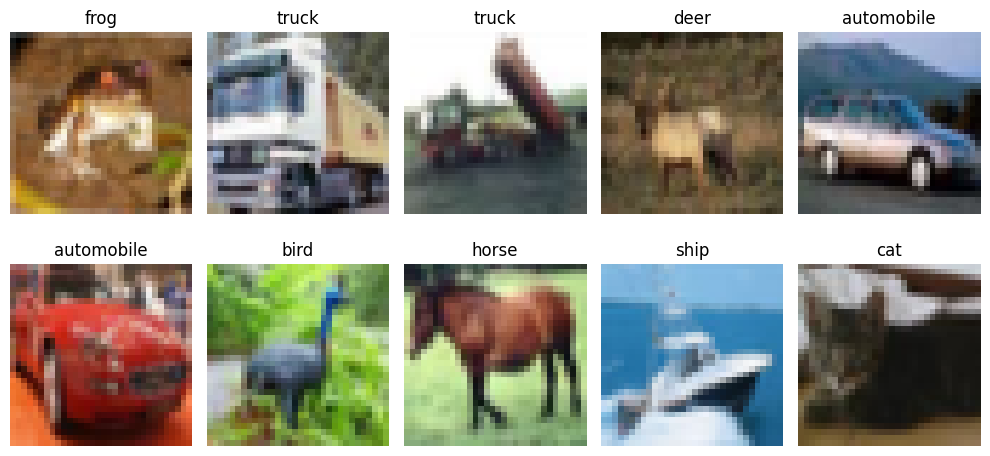

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.2685 - loss: 1.9879 - val_accuracy: 0.3304 - val_loss: 1.8437
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3171 - loss: 1.8648 - val_accuracy: 0.3590 - val_loss: 1.7829
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3322 - loss: 1.8317 - val_accuracy: 0.3692 - val_loss: 1.7789
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3466 - loss: 1.7853 - val_accuracy: 0.3836 - val_loss: 1.7368
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3574 - loss: 1.7630 - val_accuracy: 0.3968 - val_loss: 1.7029
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3656 - loss: 1.7417 - val_accuracy: 0.3802 - val_loss: 1.7187
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.3719 - loss: 1.7270 - val_accuracy: 0.3880 - val_loss: 1.7103
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3723 - loss: 1.7188 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4176 - loss: 1.6800
ANN Test Accuracy: 0.41760000586509705


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.4628 - loss: 1.4983 - val_accuracy: 0.5602 - val_loss: 1.2546
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.6024 - loss: 1.1353 - val_accuracy: 0.6086 - val_loss: 1.1250
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.6708 - loss: 0.9433 - val_accuracy: 0.6270 - val_loss: 1.0658
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.7126 - loss: 0.8250 - val_accuracy: 0.6462 - val_loss: 1.0611
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7436 - loss: 0.7370 - val_accuracy: 0.6482 - val_loss: 1.1618
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.7728 - loss: 0.6536 - val_accuracy: 0.7020 - val_loss: 0.9555
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7955 - loss: 0.5828 - val_accuracy: 0.7302 - val_loss: 0.8158
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.8141 - loss: 0

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7110 - loss: 0.9960
CNN Test Accuracy: 0.7110000252723694


## 📈 Compare Learning Curves

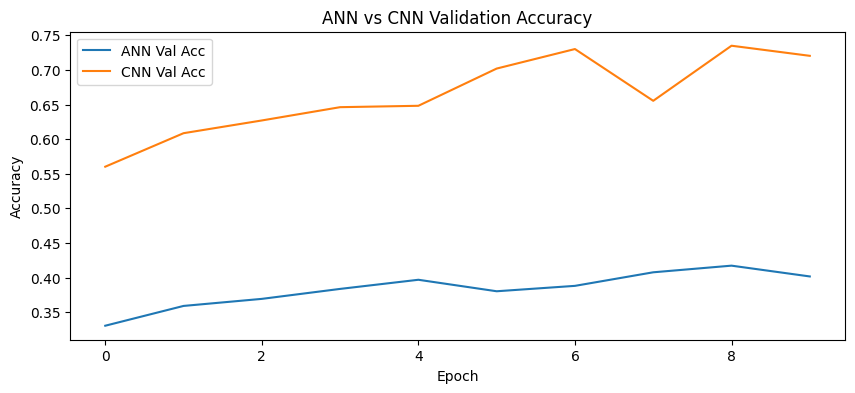

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4176
1,CNN,0.7110


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [13]:
# Create a deeper ANN model
deeper_ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deeper_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train and evaluate
deeper_ann_history = deeper_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

_, deeper_ann_acc = deeper_ann_model.evaluate(x_test_flat, y_test)
print(f"Deeper ANN Test Accuracy: {deeper_ann_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.2516 - loss: 2.0221 - val_accuracy: 0.3086 - val_loss: 1.8778
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3036 - loss: 1.8900 - val_accuracy: 0.3548 - val_loss: 1.8215
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3263 - loss: 1.8419 - val_accuracy: 0.3524 - val_loss: 1.7769
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3393 - loss: 1.8098 - val_accuracy: 0.3610 - val_loss: 1.7637
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3460 - loss: 1.7892 - val_accuracy: 0.3782 - val_loss: 1.7597
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3517 - loss: 1.7745 - val_accuracy: 0.3826 - val_loss: 1.7355
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3572 - loss: 1.7587 - val_accuracy: 0.3880 - val_loss: 1.7242
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3633 - loss: 1.7471 - 

In [14]:
# Modified CNN with scaled up filters
wider_cnn_model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

wider_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

wider_cnn_history = wider_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

_, wider_cnn_acc = wider_cnn_model.evaluate(x_test_norm, y_test)
print(f"Wider CNN Test Accuracy: {wider_cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 287ms/step - accuracy: 0.4559 - loss: 1.5246 - val_accuracy: 0.5716 - val_loss: 1.1697
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 293ms/step - accuracy: 0.6101 - loss: 1.1288 - val_accuracy: 0.5588 - val_loss: 1.2368
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.6753 - loss: 0.9419 - val_accuracy: 0.6122 - val_loss: 1.1461
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.7234 - loss: 0.8046 - val_accuracy: 0.6376 - val_loss: 1.0553
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 286ms/step - accuracy: 0.7600 - loss: 0.6979 - val_accuracy: 0.6772 - val_loss: 0.9270
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 285ms/step - accuracy: 0.7868 - loss: 0.6060 - val_accuracy: 0.7096 - val_loss: 0.8874
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 286ms/step - accuracy: 0.8184 - loss: 0.5209 - val_accuracy: 0.6828 - val_loss: 0.9776
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 285ms/step - accuracy: 0.8400 -

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping monitor
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

early_stop_model = models.clone_model(wider_cnn_model)
early_stop_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es_history = early_stop_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

_, es_acc = early_stop_model.evaluate(x_test_norm, y_test)
print(f"CNN with EarlyStopping Accuracy: {es_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 287ms/step - accuracy: 0.4592 - loss: 1.5122 - val_accuracy: 0.4470 - val_loss: 1.6445
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 288ms/step - accuracy: 0.6089 - loss: 1.1238 - val_accuracy: 0.3742 - val_loss: 1.9619
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 286ms/step - accuracy: 0.6773 - loss: 0.9308 - val_accuracy: 0.5862 - val_loss: 1.1752
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 285ms/step - accuracy: 0.7199 - loss: 0.8041 - val_accuracy: 0.6952 - val_loss: 0.8884
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 286ms/step - accuracy: 0.7627 - loss: 0.6891 - val_accuracy: 0.6912 - val_loss: 0.9358
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 285ms/step - accuracy: 0.7916 - loss: 0.5967 - val_accuracy: 0.7446 - val_loss: 0.7602
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 282ms/step - accuracy: 0.8213 - loss: 0.5084 - val_accuracy: 0.7302 - val_loss: 0.8343
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 283ms/step - accuracy: 0.8442 -

In [16]:
# Define Augmentation Layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
aug_cnn_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

_, aug_cnn_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(f"Augmented CNN Test Accuracy: {aug_cnn_acc:.4f}")

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 217s 303ms/step - accuracy: 0.3805 - loss: 1.7195 - val_accuracy: 0.4292 - val_loss: 1.6351
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 302ms/step - accuracy: 0.4870 - loss: 1.4475 - val_accuracy: 0.5586 - val_loss: 1.2403
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 264s 305ms/step - accuracy: 0.5373 - loss: 1.3127 - val_accuracy: 0.5730 - val_loss: 1.2248
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.4325 - loss: 1.6352
Augmented CNN Test Accuracy: 0.4325


In [17]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model Architecture": [
        "Baseline ANN",
        "Deeper ANN (Task 1)",
        "Baseline CNN",
        "Wider CNN (Task 2)",
        "CNN + EarlyStopping (Task 3 & 4)",
        "Augmented CNN (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        deeper_ann_acc,
        cnn_test_acc,
        wider_cnn_acc,
        es_acc,
        aug_cnn_acc
    ]
})

baseline_cnn_val = cnn_test_acc
final_comparison["Improvement vs Baseline CNN"] = final_comparison["Test Accuracy"].apply(
    lambda x: f"{x - baseline_cnn_val:+.4f}" if x in [wider_cnn_acc, es_acc, aug_cnn_acc] else "N/A"
)

print("📊 FINAL EXPERIMENT COMPARISON TABLE")
display(final_comparison)

📊 FINAL EXPERIMENT COMPARISON TABLE


,Model Architecture,Test Accuracy,Improvement vs Baseline CNN
0,Baseline ANN,0.4176,N/A
1,Deeper ANN (Task 1),0.4265,N/A
2,Baseline CNN,0.7110,N/A
3,Wider CNN (Task 2),0.6815,-0.0295
4,CNN + EarlyStopping (Task 3 & 4),0.7303,+0.0193
5,Augmented CNN (Task 5),0.4325,-0.2785


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**